Files already downloaded and verified
saved plots/cifar-10_clean+noisy_train_012922.png


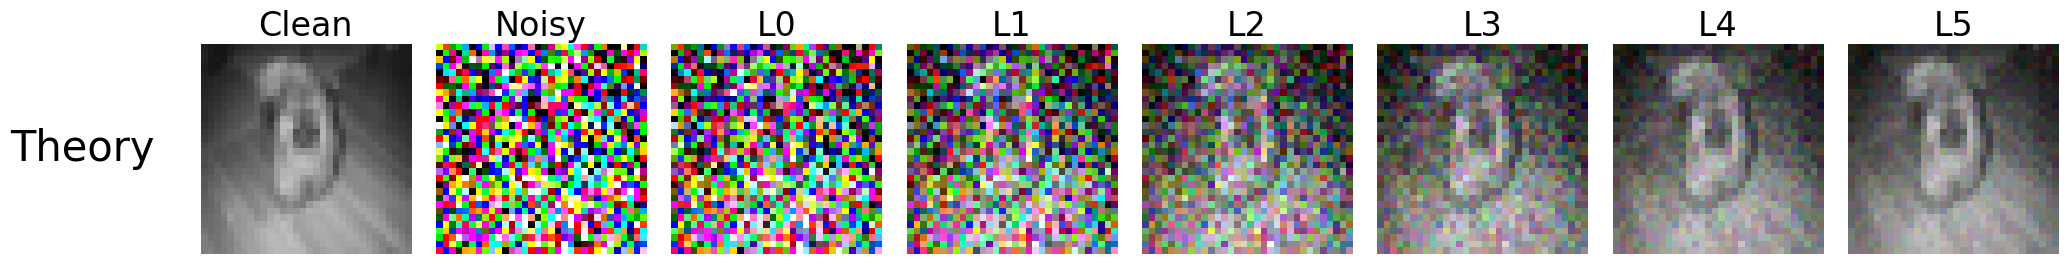

saved plots/cifar-10_pure_noise_train_012922.png


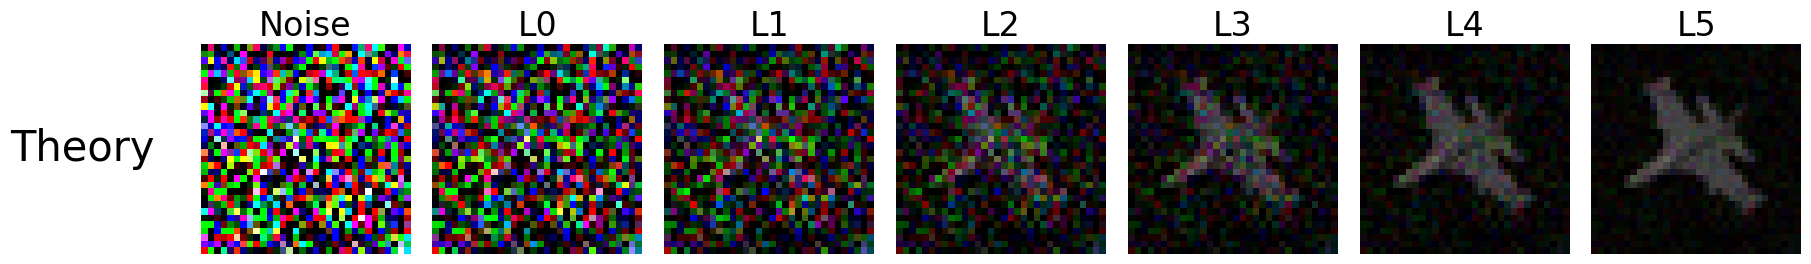

saved plots/mnist_clean+noisy_train_012924.png


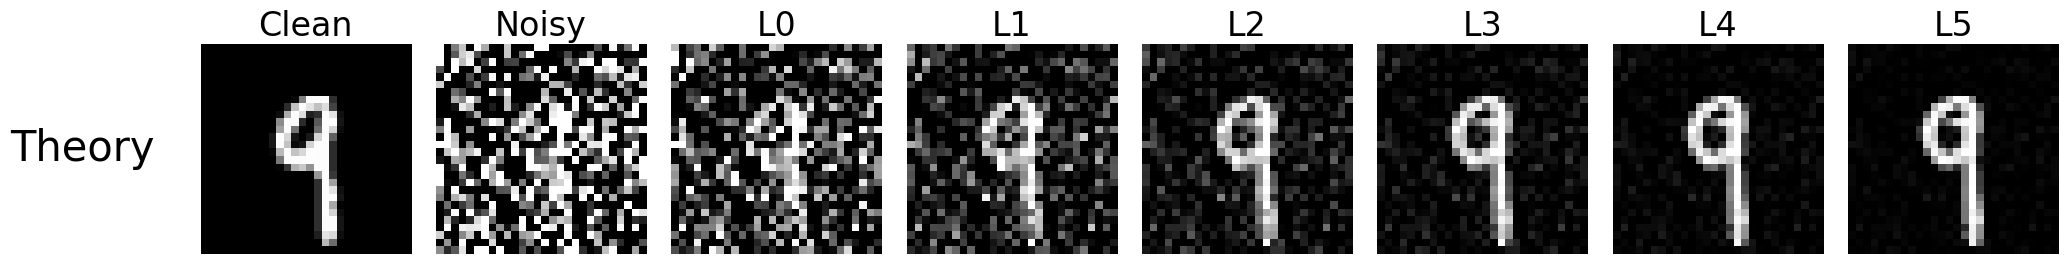

saved plots/mnist_pure_noise_train_012924.png


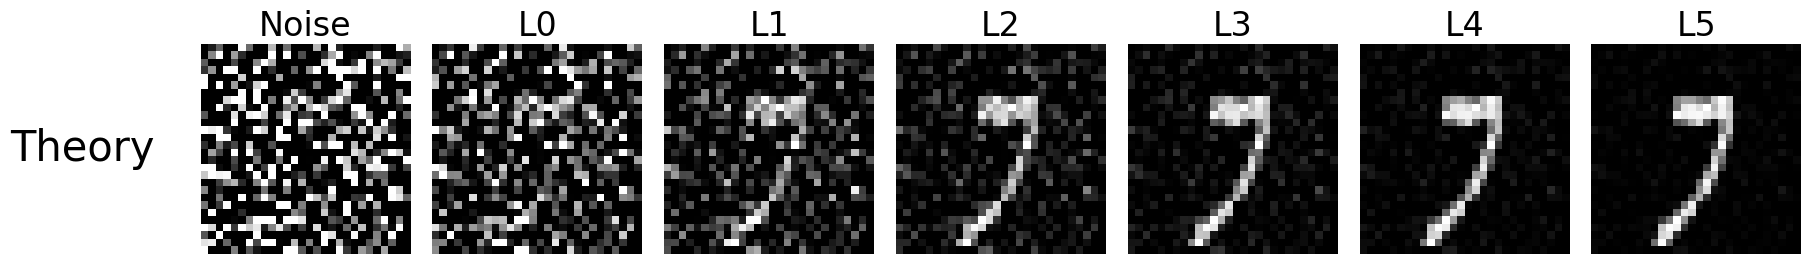

In [1]:
#Note this cell should be ran last as it. assumes pre existing models
# PARAMETERS
MODELS_TO_PLOT       = ["free_theory", "pure_theory"]
SHOW_TITLE           = False                           
TITLE_TEXT           = "Denoising Trajectories"        # ignored if SHOW_TITLE=False
TITLE_FONTSIZE       = 40
ROW_LABEL_FONTSIZE   = 30
COL_CAPTION_FONTSIZE = 24


import re, random, datetime as dt, importlib.util, numpy as np
from pathlib import Path
import torch, torchvision, matplotlib.pyplot as plt
ROOT = Path.cwd()        # wherever the notebook lives

# dataset / checkpoint config
L_CIFAR, SIG_CIFAR = 6, 1.0
L_MNIST, SIG_MNIST = 6, 1.0

BASE_CIFAR = ROOT / "fast_layersweeps"          
BASE_MNIST = ROOT / "fast_layersweeps_mnist"   
SRC        = ROOT / "DenoisingTesting.py"       

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  checkpoint finder 
PAT = re.compile(
    r"""ckpt_(?P<tag>.+?)_L(?P<L>\d+)_ep(?P<ep>\d+)_lr[^_]+_sig(?P<sig>[^_]+)\.pt$""",
    re.X,
)

def find_ckpt(base: Path, *, tag: str, L: int, sigma: float) -> Path | None:
    best, best_ep = None, -1
    for pt in base.rglob(f"ckpt_{tag}_L{L}_ep*_lr*_sig*.pt"):
        m = PAT.match(pt.name)
        if not m or abs(float(m["sig"]) - sigma) > 1e-6:
            continue
        ep = int(m["ep"])
        if ep > best_ep:
            best_ep, best = ep, pt
    return best

ck = {
    "cifar": {
        "free_theory": find_ckpt(BASE_CIFAR, tag="rbf_free_theory",   L=L_CIFAR, sigma=SIG_CIFAR),
        "free_random": find_ckpt(BASE_CIFAR, tag="rbf_free_random",   L=L_CIFAR, sigma=SIG_CIFAR),
        "constrained": find_ckpt(BASE_CIFAR, tag="rbf_constr_theory", L=L_CIFAR, sigma=SIG_CIFAR),
    },
    "mnist": {
        "free_theory": find_ckpt(BASE_MNIST, tag="rbf_free_theory",   L=L_MNIST, sigma=SIG_MNIST),
        "free_random": find_ckpt(BASE_MNIST, tag="rbf_free_random",   L=L_MNIST, sigma=SIG_MNIST),
        "constrained": find_ckpt(BASE_MNIST, tag="rbf_constr_theory", L=L_MNIST, sigma=SIG_MNIST),
    },
}

#  import model code 
spec = importlib.util.spec_from_file_location("denoise", SRC)
den  = importlib.util.module_from_spec(spec); spec.loader.exec_module(den)  # type: ignore
DenoiseTransformer, theory_initialise = den.DenoiseTransformer, den.theory_initialise

#  dataset loaders (raw pixel) 
def cifar_raw():
    ds   = torchvision.datasets.CIFAR10("./data", train=True, download=True,
                                        transform=torchvision.transforms.ToTensor())
    imgs = torch.stack([x for x, _ in ds])
    X    = imgs.view(len(imgs), -1).to(device)
    return X, lambda v: v.flatten().view(3,32,32).clamp(0,1).permute(1,2,0).cpu()

def mnist_raw():
    ds   = torchvision.datasets.MNIST("./data", train=True, download=True,
                                      transform=torchvision.transforms.ToTensor())
    imgs = ds.data.unsqueeze(1).float() / 255.0
    X    = imgs.view(len(imgs), -1).to(device)
    return X, lambda v: v.flatten().view(28,28).clamp(0,1).cpu()

#  split helper (seed=0) 
def train_split(N: int, frac: float = 0.9):
    torch.manual_seed(0)
    perm = torch.randperm(N, device=device)
    n_tr = int(frac * N)
    return perm[:n_tr]

#  model builder 
def build_model(path: Path | None, L: int, sigma: float,
                *, load_ckpt: bool, constrained: bool):
    m = DenoiseTransformer(L, kernel="rbf").to(device)
    if load_ckpt and path is not None:
        blob = torch.load(path, map_location="cpu")
        m.load_state_dict(blob.get("state_dict", blob), strict=False)
    elif load_ckpt and path is None:
        return None
    else:
        theory_initialise(m, sigma0=sigma, sigma_min=sigma * 1e-3)
        if constrained:
            for lyr in m.layers:
                lyr.log_gamma.requires_grad_(False)
    m.eval()
    return m

#  plotting helpers 
def caption(col: int, title: str) -> str:
    return ("Clean" if col == 0 else "Noisy" if col == 1 else f"L{col-2}") \
        if title == "clean+noisy" else ("Noise" if col == 0 else f"L{col-1}")

@torch.no_grad()
def layer_path(model, keys, q):
    outs = [q]
    for lyr in model.layers:
        q = lyr(keys, q); outs.append(q)
    return outs

def visualise(dataset: str, L: int, sigma: float,
              loader, ck_dict: dict[str, Path | None]):

    X, to_img = loader()
    train_idx = train_split(len(X))
    keys      = X[train_idx]                          # dictionary = train split
    idx       = int(train_idx[random.randint(0, len(train_idx) - 1)])  # sample also from train

    clean = X[idx].unsqueeze(0)
    noisy = clean + sigma * torch.randn_like(clean)
    noise = sigma * torch.randn_like(clean)

    models = []
    for tag in MODELS_TO_PLOT:
        if tag == "free_theory":
            mdl = build_model(ck_dict["free_theory"], L, sigma,
                              load_ckpt=True, constrained=False)
            name = "Trained"
        elif tag == "pure_theory":
            mdl = build_model(None, L, sigma,
                              load_ckpt=False, constrained=False)
            name = "Theory"
        else:
            continue
        if mdl is not None:
            models.append((name, mdl))

    stamp = dt.datetime.now().strftime("%H%M%S")

    def grid(seed, title):
        imgs_test = seed(models[0][1])
        cols      = len(imgs_test)
        rows      = len(models)
        fig, ax   = plt.subplots(rows, cols, figsize=(cols*2.6, rows*2.6))
        ax        = np.atleast_2d(ax)

        if SHOW_TITLE:
            fig.suptitle(TITLE_TEXT, fontsize=TITLE_FONTSIZE)

        for r, (lbl, mdl) in enumerate(models):
            imgs = seed(mdl)
            for c, img in enumerate(imgs):
                ax[r, c].imshow(
                    to_img(img),
                    cmap=None if dataset == "CIFAR-10" else "gray",
                )
                ax[r, c].axis("off")
                if r == 0:
                    ax[r, c].set_title(
                        caption(c, title), fontsize=COL_CAPTION_FONTSIZE)
            ax[r, 0].text(
                -0.22, 0.5, lbl, ha="right", va="center",
                transform=ax[r, 0].transAxes,
                fontsize=ROW_LABEL_FONTSIZE,
            )

        plt.tight_layout(rect=[0,0,1,0.97] if SHOW_TITLE else [0,0,1,1])
        out = Path("plots")/f"{dataset.lower()}_{title}_train_{stamp}.png"
        out.parent.mkdir(exist_ok=True)
        plt.savefig(out, dpi=200)
        print("saved", out)
        plt.show()

    grid(
        lambda m: [clean.squeeze(), noisy.squeeze()]
        + [t.squeeze() for t in layer_path(m, keys, noisy)[1:]],
        "clean+noisy",
    )
    grid(
        lambda m: [noise.squeeze()]
        + [t.squeeze() for t in layer_path(m, keys, noise)[1:]],
        "pure_noise",
    )

#  run visualisations 
visualise("CIFAR-10", L_CIFAR, SIG_CIFAR, cifar_raw, ck["cifar"])
visualise("MNIST",    L_MNIST, SIG_MNIST, mnist_raw,  ck["mnist"])
